<a href="https://colab.research.google.com/github/oswram19/parcial4_oswaldoramirez_1764382012/blob/main/correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/oswram19/parcial4_oswaldoramirez_1764382012/refs/heads/main/data/clave_D_correlacion.csv")
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,D-C0001,28,1019,8,62.42,7.26,1,5,15.34,504.69
1,D-C0002,45,1129,6,66.92,6.71,2,3,33.45,426.35
2,D-C0003,44,1085,8,68.72,8.38,1,5,20.62,520.35
3,D-C0004,35,1583,9,101.45,6.92,1,6,16.99,834.77
4,D-C0005,38,876,10,79.69,6.97,3,8,29.21,745.63


# verificar nulos o tipo de datos

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          236 non-null    object 
 1   edad                236 non-null    int64  
 2   ingresos_mensuales  236 non-null    int64  
 3   frecuencia_compra   236 non-null    int64  
 4   ticket_promedio     235 non-null    float64
 5   satisfaccion        235 non-null    float64
 6   reclamos            236 non-null    int64  
 7   uso_app             236 non-null    int64  
 8   tiempo_respuesta    235 non-null    float64
 9   consumo_total       236 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 18.6+ KB
None


In [6]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


isualizing Outliers for Numerical Columns

In [9]:
display(df.describe())

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,236.000000,236.000000,236.000000,235.000000,235.000000,236.000000,236.000000,235.000000,236.000000
mean,37.661017,1008.542373,7.872881,62.766340,7.622043,1.500000,5.754237,20.952255,499.803686
std,9.084212,255.764275,3.246069,15.550721,1.376957,1.697307,2.020897,5.876405,184.561886
min,18.000000,381.000000,1.000000,16.080000,1.530000,0.000000,0.000000,7.170000,37.460000
25%,32.000000,847.750000,6.000000,50.320000,7.070000,0.000000,4.000000,16.775000,385.665000
50%,37.500000,1018.000000,8.000000,62.760000,7.820000,1.000000,6.000000,20.400000,477.640000
75%,45.000000,1178.250000,9.000000,74.035000,8.370000,2.000000,7.000000,24.405000,611.317500
max,58.000000,1583.000000,30.000000,101.450000,10.000000,9.000000,10.000000,38.950000,1567.100000


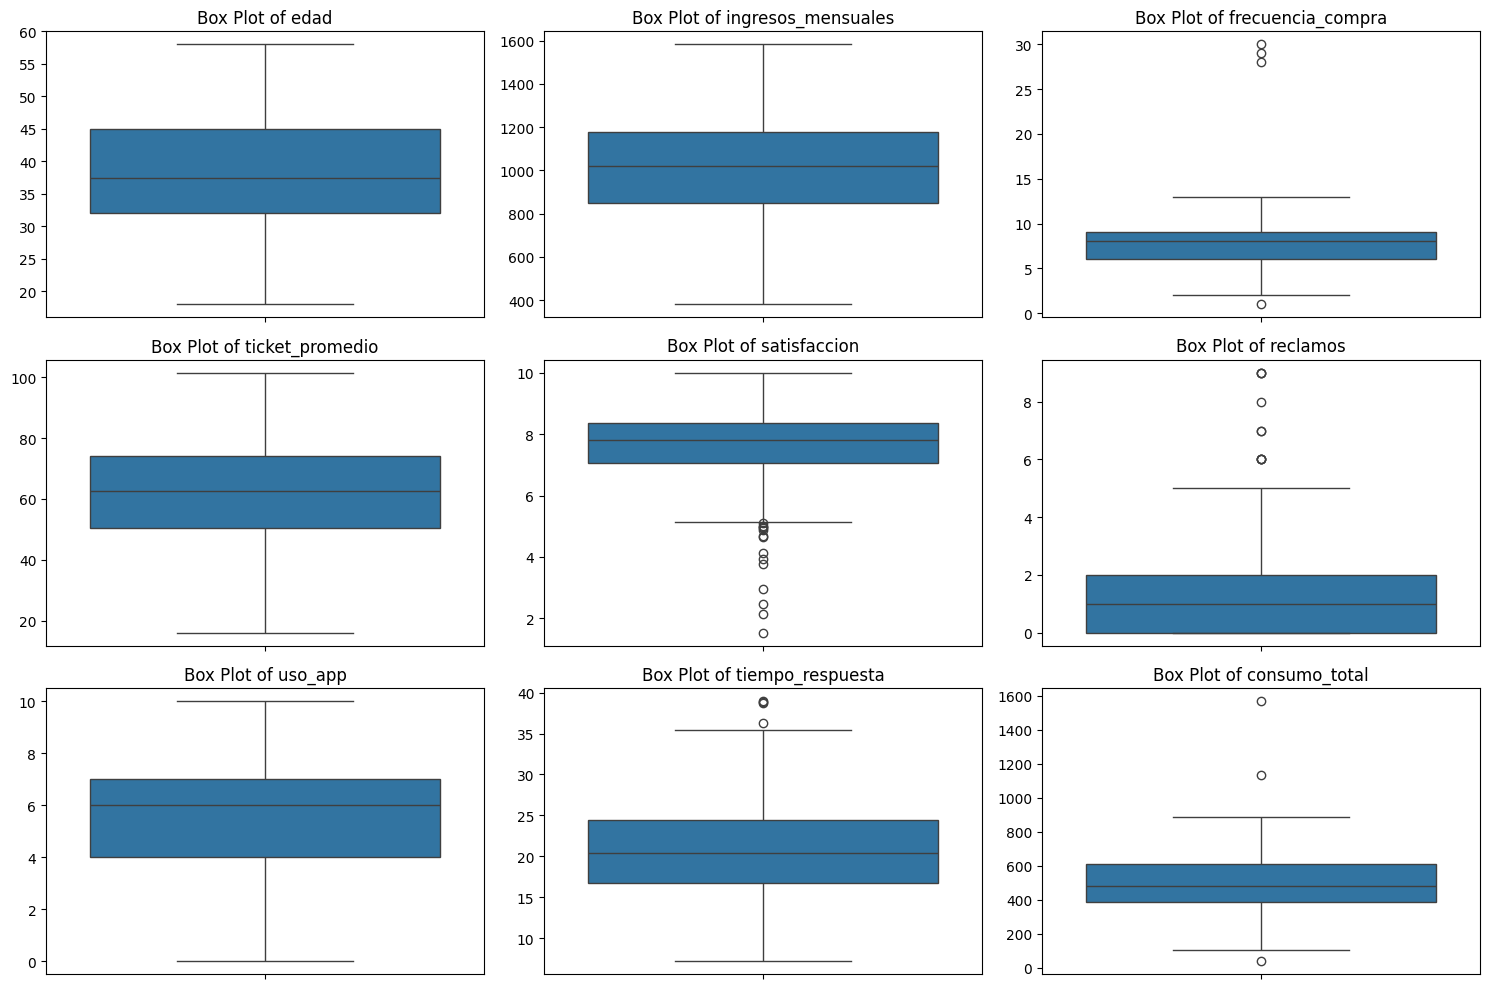

In [10]:
# Seleccione las columnas numéricas para la visualización de valores atípicos (excluyendo 'cliente_id').
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'cliente_id' in numerical_cols:
    numerical_cols.remove('cliente_id')

# Cree diagramas de caja para las columnas numéricas seleccionadas.
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Ajuste la cuadrícula de subgráficos según sea necesario.
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# Calcular la matriz de correlación

In [11]:
correlation_matrix = df[numerical_cols].corr()
display(correlation_matrix)

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,-0.021763,-0.034514,0.086738,-0.086759,0.104874,0.115280,0.073082,0.026429
ingresos_mensuales,-0.021763,1.000000,0.057653,0.575299,0.057425,-0.023183,0.100913,-0.020929,0.395898
frecuencia_compra,-0.034514,0.057653,1.000000,-0.029179,0.213286,-0.129755,0.355883,-0.221785,0.764457
ticket_promedio,0.086738,0.575299,-0.029179,1.000000,0.009712,-0.015252,0.050240,-0.081047,0.522419
satisfaccion,-0.086759,0.057425,0.213286,0.009712,1.000000,-0.824728,0.287779,-0.618940,0.336956
reclamos,0.104874,-0.023183,-0.129755,-0.015252,-0.824728,1.000000,-0.068232,0.624487,-0.256417
uso_app,0.115280,0.100913,0.355883,0.050240,0.287779,-0.068232,1.000000,-0.180685,0.458309
tiempo_respuesta,0.073082,-0.020929,-0.221785,-0.081047,-0.618940,0.624487,-0.180685,1.000000,-0.328165
consumo_total,0.026429,0.395898,0.764457,0.522419,0.336956,-0.256417,0.458309,-0.328165,1.000000


visualizar la matriz

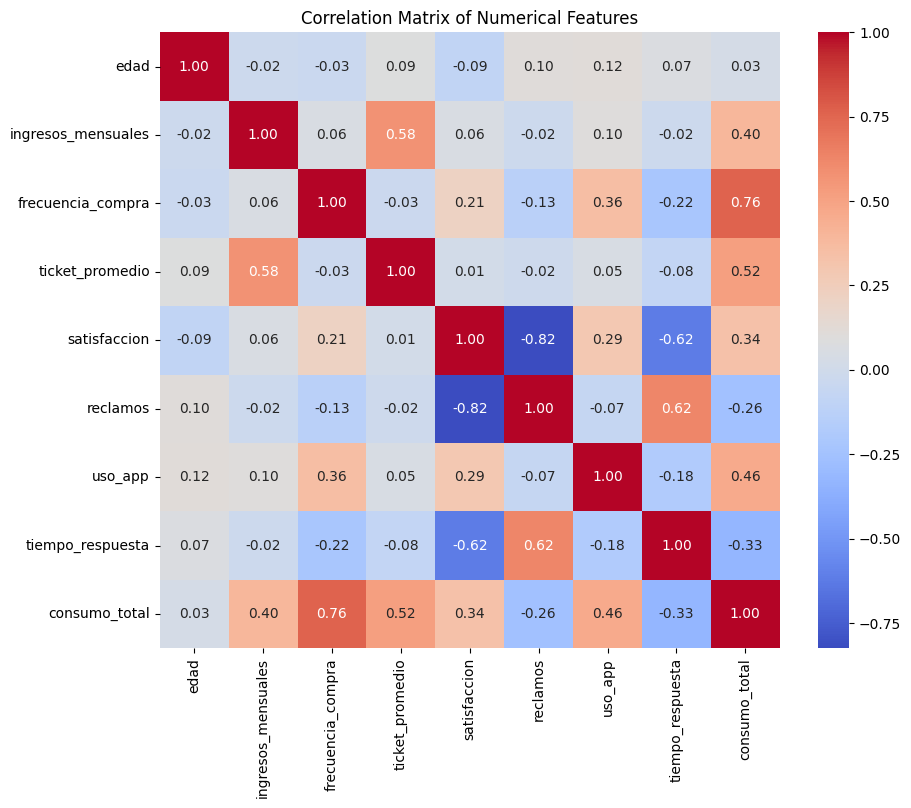

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de características numéricas')
plt.show()

# crear un mapa de calor

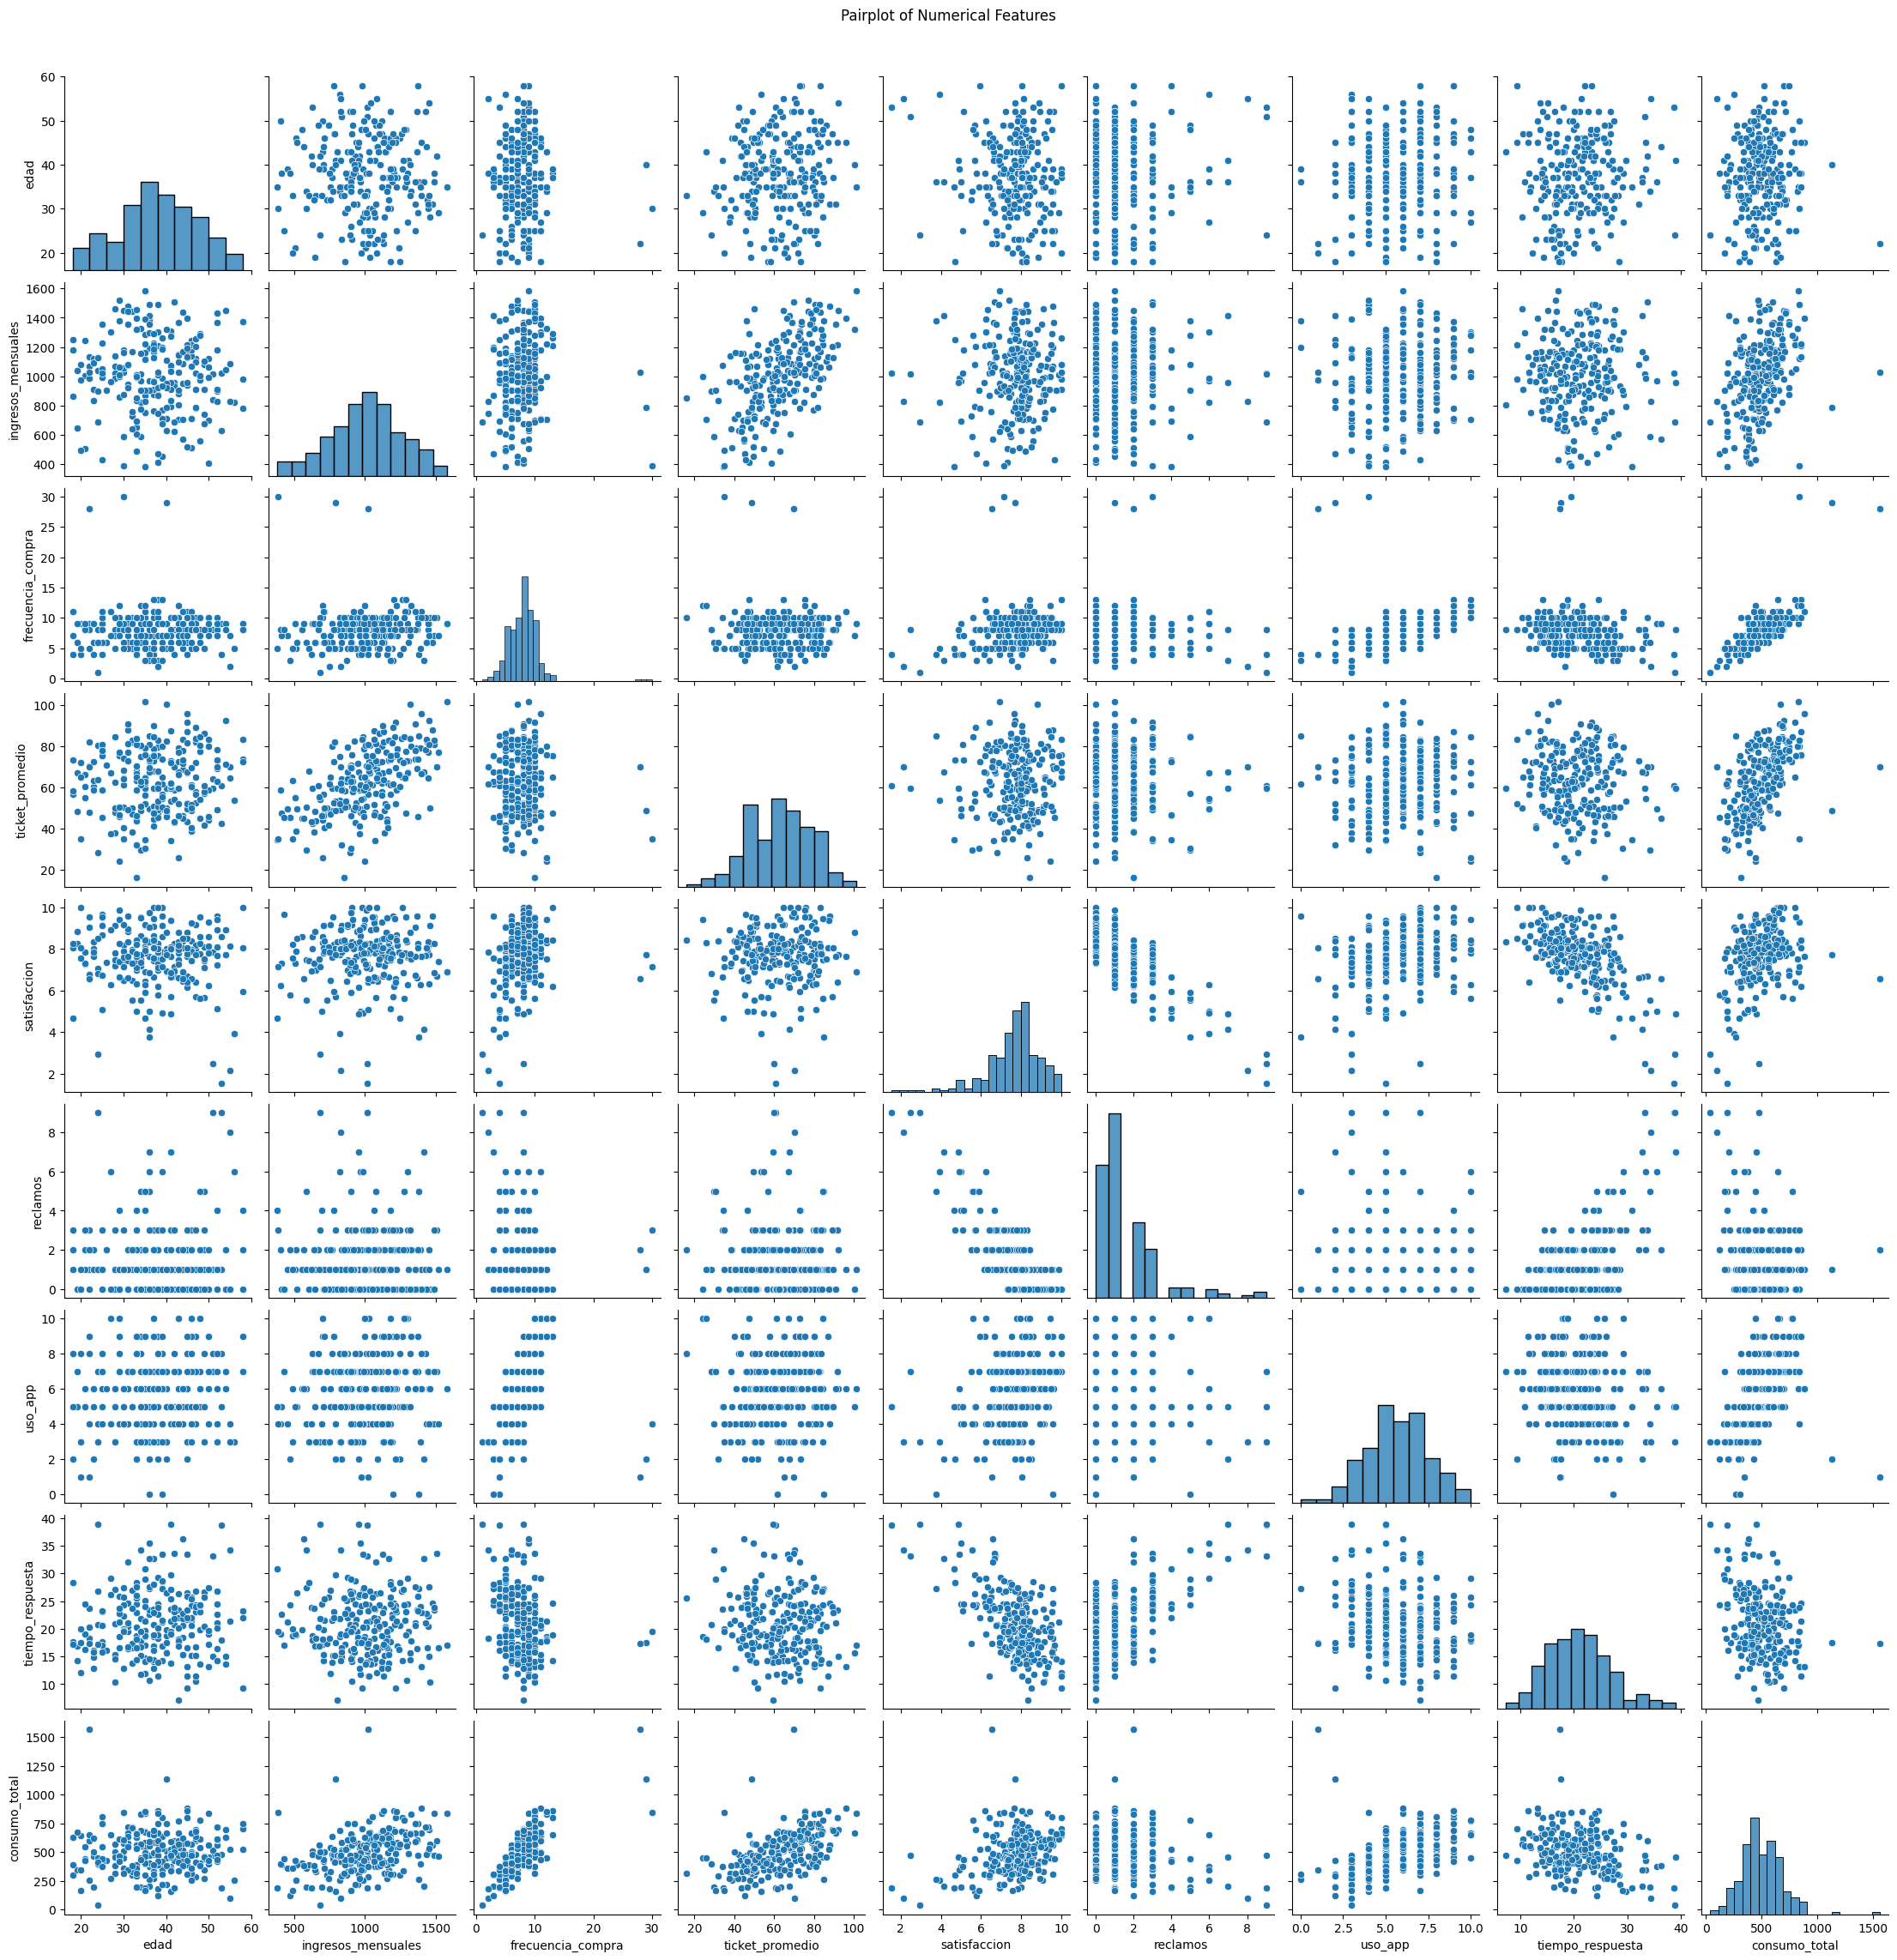

In [13]:
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02) # Adjust title position
plt.show()

### Correlaciones Positivas Más Importantes

In [14]:
print("Correlaciones positivas más importantes (coeficiente > 0.5):")

important_positive_correlations = []
# Iterar sobre la matriz de correlación para encontrar correlaciones positivas
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)): # Recorrer solo la parte superior para evitar duplicados
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        if correlation_value > 0.5: # Considerar correlaciones positivas "importantes" si son mayores a 0.5
            important_positive_correlations.append((col1, col2, correlation_value))

# Ordenar por el valor de correlación de mayor a menor
important_positive_correlations.sort(key=lambda x: x[2], reverse=True)

if not important_positive_correlations:
    print("No se encontraron correlaciones positivas fuertes (superiores a 0.5) entre las características numéricas.")
else:
    for col1, col2, value in important_positive_correlations:
        print(f"- {col1} y {col2}: {value:.2f}")

Correlaciones positivas más importantes (coeficiente > 0.5):
- frecuencia_compra y consumo_total: 0.76
- reclamos y tiempo_respuesta: 0.62
- ingresos_mensuales y ticket_promedio: 0.58
- ticket_promedio y consumo_total: 0.52


### Correlaciones Negativas Más Importantes

In [15]:
print("Correlaciones negativas más importantes (coeficiente < -0.5):")

important_negative_correlations = []
# Iterar sobre la matriz de correlación para encontrar correlaciones negativas
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)): # Recorrer solo la parte superior para evitar duplicados
        col1 = correlation_matrix.columns[i]
        col2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]

        if correlation_value < -0.5: # Considerar correlaciones negativas "importantes" si son menores a -0.5
            important_negative_correlations.append((col1, col2, correlation_value))

# Ordenar por el valor absoluto de correlación de mayor a menor
important_negative_correlations.sort(key=lambda x: abs(x[2]), reverse=True)

if not important_negative_correlations:
    print("No se encontraron correlaciones negativas fuertes (inferiores a -0.5) entre las características numéricas.")
else:
    for col1, col2, value in important_negative_correlations:
        print(f"- {col1} y {col2}: {value:.2f}")

Correlaciones negativas más importantes (coeficiente < -0.5):
- satisfaccion y reclamos: -0.82
- satisfaccion y tiempo_respuesta: -0.62


### Explicación de Relaciones entre Variables

Basándonos en la matriz de correlación y los resultados de las correlaciones positivas y negativas importantes, podemos destacar las siguientes relaciones:

1.  **Frecuencia de compra y Consumo total (Correlación Positiva Fuerte):** Existe una correlación positiva fuerte (0.76) entre la `frecuencia_compra` y el `consumo_total`. Esto sugiere que los clientes que compran con mayor frecuencia tienden a tener un `consumo_total` más alto. Es una relación intuitiva: a más visitas, más oportunidades de gasto, lo que se traduce en un mayor consumo general.

2.  **Satisfacción y Reclamos (Correlación Negativa Muy Fuerte):** Observamos una correlación negativa muy fuerte (-0.82) entre la `satisfaccion` del cliente y el número de `reclamos`. Esto es esperado y deseable: a mayor satisfacción, menor es la cantidad de reclamos que los clientes presentan, lo que indica una buena calidad de servicio o producto.

3.  **Reclamos y Tiempo de Respuesta (Correlación Positiva Fuerte):** Hay una correlación positiva fuerte (0.62) entre los `reclamos` y el `tiempo_respuesta`. Esto podría interpretarse de varias maneras: a) Si un cliente presenta más reclamos, es posible que experimente tiempos de respuesta más largos debido a la carga o complejidad de sus problemas. b) Alternativamente, un `tiempo_respuesta` más largo puede llevar a una mayor frustración y, por ende, a más `reclamos` por parte del cliente.

4.  **Ingresos Mensuales y Ticket Promedio (Correlación Positiva Moderada):** Existe una correlación positiva moderada (0.58) entre los `ingresos_mensuales` de un cliente y su `ticket_promedio`. Esto indica que los clientes con mayores ingresos tienden a gastar más en promedio en cada transacción, lo cual es una tendencia común en el comportamiento del consumidor.

5.  **Satisfacción y Tiempo de Respuesta (Correlación Negativa Fuerte):** Existe una correlación negativa fuerte (-0.62) entre la `satisfaccion` y el `tiempo_respuesta`. Similar a la relación con los reclamos, un menor `tiempo_respuesta` (es decir, una respuesta más rápida) está asociado con una mayor `satisfaccion` del cliente, lo que subraya la importancia de la eficiencia en el servicio.

### Conclusiones y Implicaciones para la Empresa

Las relaciones identificadas entre las variables proporcionan información valiosa que la empresa puede utilizar para mejorar sus estrategias y operaciones:

1.  **Fidelización y Valor del Cliente:** La fuerte correlación positiva entre `frecuencia_compra` y `consumo_total` (0.76) indica que los clientes más frecuentes son también los que más gastan. La empresa debería enfocar sus esfuerzos en programas de fidelización que incentiven la repetición de compra. Identificar a estos clientes de alta frecuencia permite ofrecerles promociones personalizadas o recompensas exclusivas para mantener y aumentar su lealtad y su gasto.

2.  **Gestión de la Satisfacción y Reducción de Reclamos:** La fuerte correlación negativa entre `satisfaccion` y `reclamos` (-0.82), junto con la correlación negativa entre `satisfaccion` y `tiempo_respuesta` (-0.62), subraya la importancia crítica de la satisfacción del cliente. Invertir en mejorar la calidad del servicio, la experiencia del producto y, crucialmente, reducir los `tiempo_respuesta` a consultas o problemas, resultará directamente en una menor cantidad de `reclamos` y, por ende, en una mayor `satisfaccion` del cliente. Esto puede llevar a una mejor reputación de la marca y a la retención de clientes.

3.  **Optimización de la Atención al Cliente:** La correlación positiva entre `reclamos` y `tiempo_respuesta` (0.62) sugiere que un manejo ineficiente de los reclamos (tiempos de respuesta largos) puede exacerbar la situación y potencialmente generar más reclamos o insatisfacción. La empresa debería priorizar la agilización de los procesos de atención al cliente y la resolución de problemas para mejorar la eficiencia y, por consiguiente, la satisfacción del cliente.

4.  **Segmentación de Clientes y Estrategias de Venta:** La correlación moderada entre `ingresos_mensuales` y `ticket_promedio` (0.58) permite a la empresa segmentar a sus clientes por nivel de ingresos. Aquellos con mayores ingresos tienden a tener un `ticket_promedio` más alto. Esto podría guiar estrategias de marketing y ventas dirigidas, ofreciendo productos o servicios premium a segmentos de mayores ingresos y ajustando las ofertas a otros grupos para maximizar las ventas en todos los segmentos.